RQ4: How does German media portrayal of governments change during the 2025 bundestags election?

Source: tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv
Dislaimer: due to the large size of the csv-file we had to compromise it and put it as a .rar file into the Data folder, so if someone wants to change something you need to decompromise it locally :)

We examine the tone towards government related actors around the Bundestags Election on 23rd February 2025.

In [149]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

sns.set(style="whitegrid")

DATA_PATH = "Data/tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv"  


In [150]:
df = pd.read_csv(DATA_PATH)

print(df.columns)
df.head()


Index(['DATE', 'SourceCommonName', 'url', 'V2Persons', 'V2Organizations',
       'V2Tone'],
      dtype='object')


,DATE,SourceCommonName,url,V2Persons,V2Organizations,V2Tone
0,20231008000000,foxnews.com,https://www.foxnews.com/us/michigan-father-cha...,"Kayvon Barrett,279","Child Protective Services,1000;District Court ...","-8.62068965517241,0.689655172413793,9.31034482..."
1,20231008000000,foxnews.com,https://www.foxnews.com/us/jewish-institutions...,"Noah Farkas,1417;Sarah Rumpf-Whitten,2990;Simc...","Jewish Federation,619;Jewish Federation,1159;J...","-3.57852882703777,3.18091451292246,6.759443339..."
2,20231008000000,foxnews.com,https://www.foxnews.com/politics/biden-admin-u...,"Antony Blinken,1657;Brooke Singman,3452;Lloyd ...","United States,238;United States,786;United Sta...","-4.68468468468468,1.62162162162162,6.306306306..."
3,20231008000000,zdf.de,https://www.zdf.de/filme/spielfilm-highlights/...,NaN,NaN,"1.04166666666667,3.125,2.08333333333333,5.2083..."
4,20231008003000,foxnews.com,https://www.foxnews.com/us/mugshots-week-oct-1...,"Tonya Blair,11",NaN,"-9.43396226415094,0,9.43396226415094,9.4339622..."


In [151]:
# extract date and time and format it
df["Datum_Zeit"] = pd.to_datetime(df["DATE"].astype(str).str.slice(0, 8), format="%Y%m%d")
df["Datum"] = df["Datum_Zeit"].dt.date

# Filter just german news outlets
de_mask = df["SourceCommonName"].str.contains("tagesschau.de|zdf.de|bild.de", na=False)
df_de = df[de_mask].copy()

df_de["SourceCommonName"].value_counts()




SourceCommonName
bild.de                 91487
tagesschau.de           33218
autobild.de              9014
zdf.de                   6396
aktionen.autobild.de        1
Name: count, dtype: int64

In [152]:
#extract overall tone from V2Tone column
def extract_tone(v):
    try:
        return float(str(v).split(",")[0])
    except Exception:
        return None

df_de["Tone"] = df_de["V2Tone"].apply(extract_tone)

df_de[["Datum", "SourceCommonName", "Tone"]].head()
df_de["Tone"].describe()


count    140116.000000
mean         -2.284332
std           3.813877
min         -24.590164
25%          -4.692082
50%          -1.892744
75%           0.366300
max          19.551282
Name: Tone, dtype: float64

Election window:
Bundestags election on 23rd February 2025

We analyse three periods:
- pre -> 60 days before the election day (official election campaigns start 4-6 weeks prior to the election day in germany)
-  election -> the election day
- post -> 30 days after the election day

In [153]:
#Timespan of the dataset
print('Dataset begins:',df['Datum'].min() , '\nDataset ends:',df['Datum'].max())


Dataset begins: 2023-10-08 
Dataset ends: 2026-02-28


In [154]:
election_day = pd.to_datetime("2025-02-23")

PRE_DAYS = 60
POST_DAYS = 30

start_pre = election_day - pd.Timedelta(days=PRE_DAYS)
end_post = election_day + pd.Timedelta(days=POST_DAYS)

print("Pre starts:", start_pre.date(), "Post ends:", end_post.date())


Pre starts: 2024-12-25 Post ends: 2025-03-25


In [155]:
#Filter data for the window around the election
df_win = df_de[
    (df_de["Datum_Zeit"] >= start_pre) &
    (df_de["Datum_Zeit"] <= end_post)
].copy()

df_win["Datum"] = df_win["Datum_Zeit"].dt.date

print("Rows in window:", len(df_win))
df_win[["Datum", "SourceCommonName", "Tone"]].head()


Rows in window: 15583


,Datum,SourceCommonName,Tone
156497,2024-12-25,bild.de,-2.400000
156498,2024-12-25,bild.de,2.479339
156499,2024-12-25,bild.de,-13.496933
156500,2024-12-25,tagesschau.de,-2.083333
156504,2024-12-25,bild.de,-4.629630


In [156]:
#Label periods: pre, election, post
def label_period(ts):
    if ts.date() < election_day.date():
        return "pre"
    elif ts.date() == election_day.date():
        return "election"
    else:
        return "post"

df_win["period"] = df_win["Datum_Zeit"].apply(label_period)
df_win["period"].value_counts()


period
pre         10136
post         5266
election      181
Name: count, dtype: int64

In [157]:
#Identify goverment-related articles based on keywords
gov_keywords = [
    "GOVERNMENT", "BUNDESTAG", "MINIST", "CHANCELLOR",
    "PRESIDENT", "PARTY", "GERMAN", "GERMANY"
]

pattern = "|".join(gov_keywords)

mask_gov = (
    df_win["V2Persons"].astype(str).str.contains(pattern, case=False, na=False)
    | df_win["V2Organizations"].astype(str).str.contains(pattern, case=False, na=False)
)

df_gov = df_win[mask_gov].copy()

df_gov[["Datum", "SourceCommonName", "V2Persons", "V2Organizations", "Tone", "period"]].head()
len(df_gov)


2315

In [158]:
#Standardize outlet names
def map_outlet(src: str) -> str:
    s = str(src).lower()
    if "tagesschau.de" in s:
        return "Tagesschau"
    if "zdf.de" in s:
        return "ZDF"
    if "bild.de" in s:
        return "BILD"
    return src

df_gov["Outlet"] = df_gov["SourceCommonName"].apply(map_outlet)

df_gov["Outlet"].value_counts()


Outlet
Tagesschau    1167
BILD          1112
ZDF             36
Name: count, dtype: int64

In [159]:
#Aggregate tone by day, outlet and period
agg_daily = (
    df_gov
    .groupby(["Datum_Zeit", "Outlet", "period"], observed=False)["Tone"]
    .agg(avg_tone="mean", num_events="size")
    .reset_index()
)

# Nur Tage mit mindestens einem Regierungs-Event
agg_daily = agg_daily[agg_daily["num_events"] > 0].copy()

agg_daily.head()


,Datum_Zeit,Outlet,period,avg_tone,num_events
0,2024-12-25,BILD,pre,-0.007974,7
1,2024-12-25,Tagesschau,pre,-3.965340,13
2,2024-12-25,ZDF,pre,-2.416918,1
3,2024-12-26,BILD,pre,-2.004795,12
4,2024-12-26,Tagesschau,pre,-4.606648,5


In [160]:
#Summarize pre, election and post period by outlet
summary = (
    agg_daily
    .groupby(["Outlet", "period"], observed=False)
    .agg(
        mean_tone=("avg_tone", "mean"),
        median_tone=("avg_tone", "median"),
        sd_tone=("avg_tone", "std"),
        days=("avg_tone", "size")
    )
    .reset_index()
)

summary


,Outlet,period,mean_tone,median_tone,sd_tone,days
0,BILD,election,-0.543218,-0.543218,NaN,1
1,BILD,post,-1.554284,-1.443207,0.946326,30
2,BILD,pre,-2.014484,-1.994427,0.995267,60
3,Tagesschau,election,-0.914886,-0.914886,NaN,1
4,Tagesschau,post,-1.719171,-1.571250,1.016028,30
5,Tagesschau,pre,-2.301180,-2.161355,0.983656,60
6,ZDF,election,1.077262,1.077262,NaN,1
7,ZDF,post,0.233371,-0.151036,3.198460,10
8,ZDF,pre,-1.311395,-1.041667,2.894541,19


In [161]:
#Calculate differences in mean tone
diff = (
    summary
    .pivot(index="Outlet", columns="period", values="mean_tone")
    .reset_index()
)

print(diff.columns)

diff["election_minus_pre"] = diff["election"] - diff["pre"]
diff["post_minus_pre"] = diff["post"] - diff["pre"]

diff


Index(['Outlet', 'election', 'post', 'pre'], dtype='object', name='period')


period,Outlet,election,post,pre,election_minus_pre,post_minus_pre
0,BILD,-0.543218,-1.554284,-2.014484,1.471266,0.460200
1,Tagesschau,-0.914886,-1.719171,-2.301180,1.386293,0.582009
2,ZDF,1.077262,0.233371,-1.311395,2.388657,1.544766


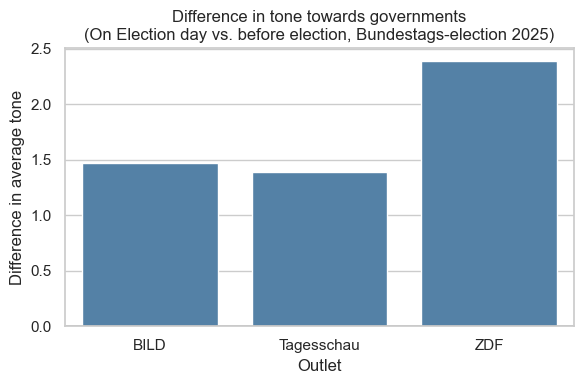

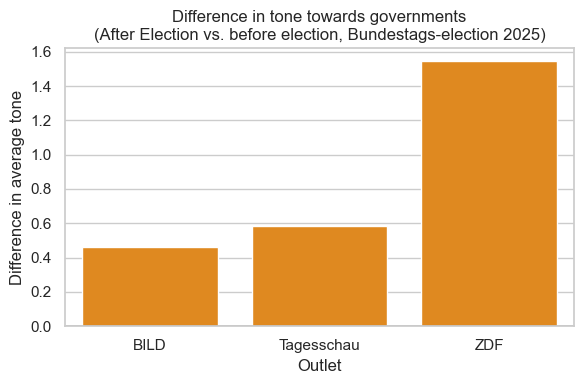

In [162]:
#Change in tone towards governments (election - pre, Bundestags-election 2025)
plt.figure(figsize=(6, 4))
sns.barplot(
    data=diff,
    x="Outlet",
    y="election_minus_pre",
    color="steelblue"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Difference in tone towards governments\n(On Election day vs. before election, Bundestags-election 2025)")
plt.xlabel("Outlet")
plt.ylabel("Difference in average tone")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(
    data=diff,
    x="Outlet",
    y="post_minus_pre",
    color="darkorange"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Difference in tone towards governments\n(After Election vs. before election, Bundestags-election 2025)")
plt.xlabel("Outlet")
plt.ylabel("Difference in average tone")
plt.tight_layout()
plt.show()


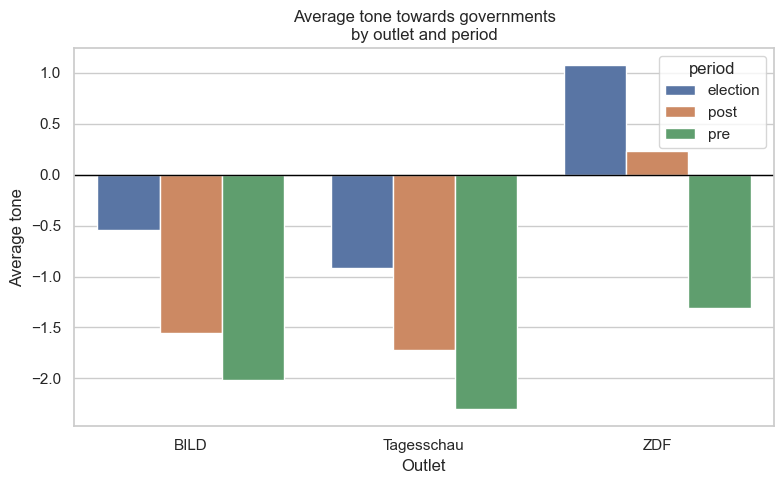

In [163]:
#Change of tone before election day, on election day and after election day
plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary,           # Outlet, period, mean_tone
    x="Outlet",
    y="mean_tone",
    hue="period"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average tone towards governments\nby outlet and period")
plt.xlabel("Outlet")
plt.ylabel("Average tone")
plt.tight_layout()
plt.show()


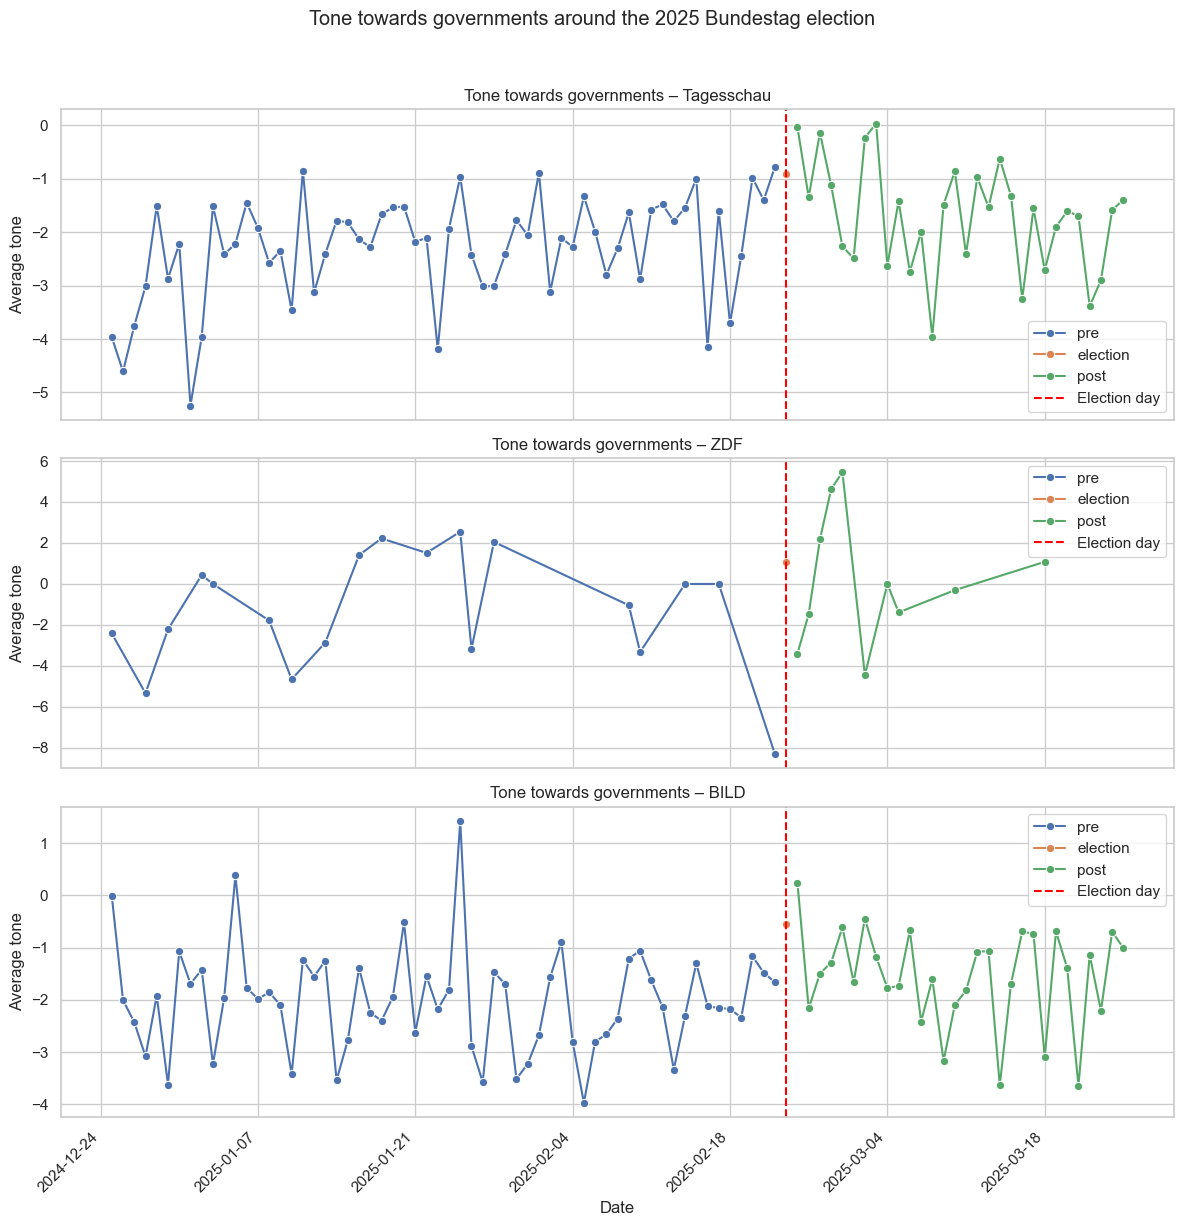

In [164]:
#Change of tone towards governments around the 2025 Bundestag election per news outlet
media_order = ["Tagesschau", "ZDF", "BILD"]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, outlet in zip(axes, media_order):
    subset = agg_daily[agg_daily["Outlet"] == outlet]

    sns.lineplot(
        data=subset,
        x="Datum_Zeit",
        y="avg_tone",
        hue="period",
        marker="o",
        ax=ax
    )
    ax.axvline(election_day, color="red", linestyle="--", label="Election day")
    ax.set_title(f"Tone towards governments – {outlet}")
    ax.set_ylabel("Average tone")
    ax.legend()

# Gemeinsame x-Achse formatieren
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # alle 2 Wochen ein Tick
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Tone towards governments around the 2025 Bundestag election", y=1.02)
plt.tight_layout()
plt.show()


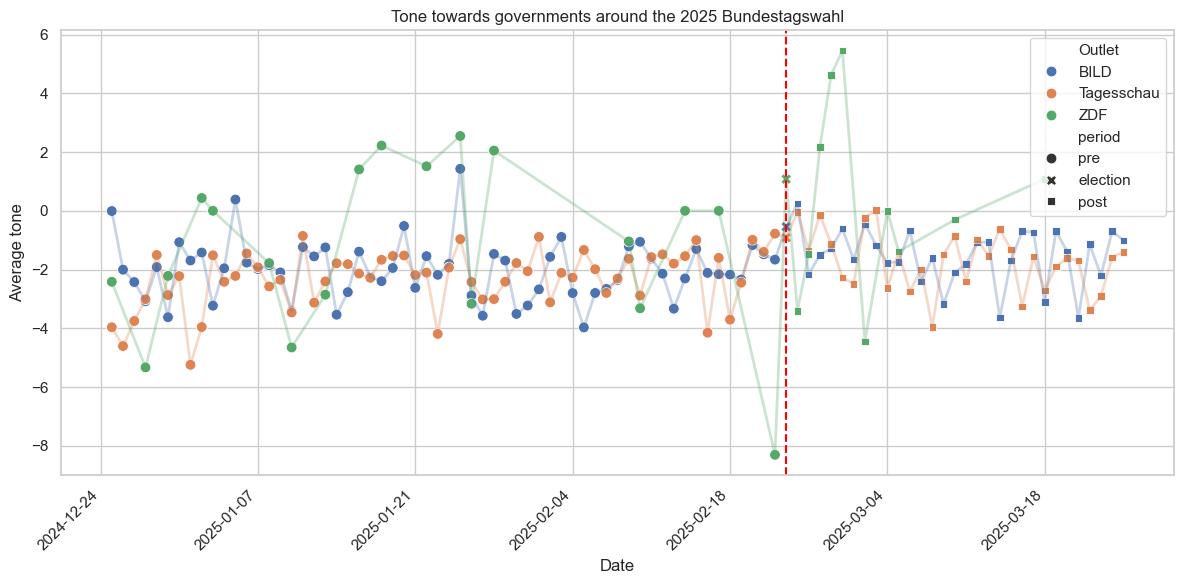

In [165]:
plt.figure(figsize=(12, 6))

#Before the election
sns.lineplot(
    data=agg_daily,
    x="Datum_Zeit",
    y="avg_tone",
    hue="Outlet",
    estimator=None,
    alpha=0.3,
    linewidth=2,
    legend=False
)

#After the election
sns.scatterplot(
    data=agg_daily,
    x="Datum_Zeit",
    y="avg_tone",
    hue="Outlet",
    style="period",
    s=60
)

plt.axvline(election_day, color="red", linestyle="--", label="Election day")

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")

plt.title("Tone towards governments around the 2025 Bundestagswahl")
plt.xlabel("Date")
plt.ylabel("Average tone")
plt.tight_layout()
plt.show()


**Interpretation of german media tone around the bundestags-election 2025:**

All three outlets Bild, Tagesschau and Zdf report on government-related actord in a dominantly negative tone in the pe-election-period with average tone values below zero (the neutral).
On election day 23rd February 2025 the average tone becomes less negative for each outlet:

- Bild moves from about -2 to -0.54,
- Tagesschau moves from -2.30 to -0.91 and
- ZDF from -1.31 to +1.08.

Nevertheless the tone becomes more negative again in the post-election period but for all outlets it remains less negative than before the election with means still above the pre-election means.

- In the pre-election period all three outlets are dominantly negative
- Around election day, Bild and Tagesschau move closer to a neutral tone while ZDF crosses into positive tone temporarily, indicating more neutral or favourable coverage of government related actord.
- In the post-election period, the tones start to drift back more negative but remain on average less negative than before.

**Summary**:
In our data sample all three german news outlets moderate their tone towards government-related actors during the election. Compared to the pre-election period, coverage on election day is systematically less negative and in some cases (ZDF) it even turns positive on average. After the election the tone becomes negative again but not as negative as pre-election, indicating a partial reversion. This pattern would suggest that the election itself is associated with a temporary balancing of coverage, rather than an escalation of criticism.
Overall, german media portrayal of government around the 2025 bundestag election appears to moderate during the election day and stabilise at a slightly less negative level afterwards.